<a href="https://colab.research.google.com/github/ashishkhetwal/Wine-Quality-Prediction-Machine-Learning/blob/main/wine_quality_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import the dependencies

In [42]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
wine_dataset = pd.read_csv('/content/winequality-red.csv')

In [44]:
wine_dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [45]:
wine_dataset.shape

(1599, 12)

In [46]:
wine_dataset.isnull().sum().sum()

np.int64(0)

Visualization

In [47]:
wine_dataset.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Number of values present for each quality value

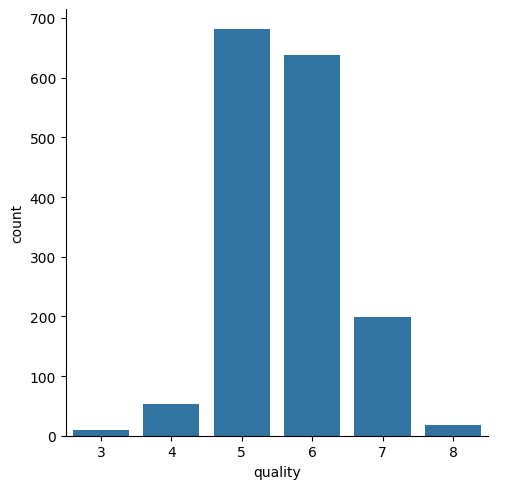

In [48]:
sns.catplot(x = 'quality', data = wine_dataset, kind = 'count')

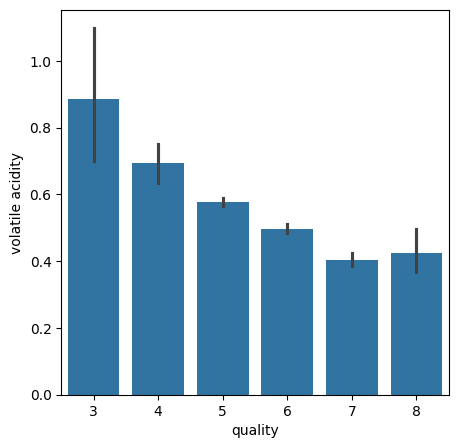

In [49]:
# volatile acidity vs quality
plot = plt.figure(figsize = (5,5))
sns.barplot(x = 'quality', y = 'volatile acidity', data = wine_dataset)
plt.show()

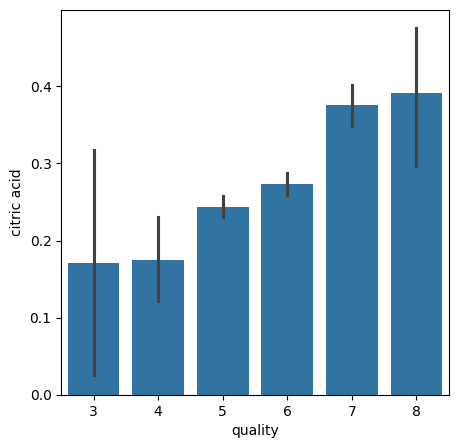

In [50]:
plot = plt.figure(figsize = (5,5))
sns.barplot(x = 'quality', y = 'citric acid', data = wine_dataset)
plt.show()

Finding correlation between the values

Positive correlation -> if one value increases other also increases.

Negative correlation -> If one value increases the other decreases.

In [51]:
correlation = wine_dataset.corr()

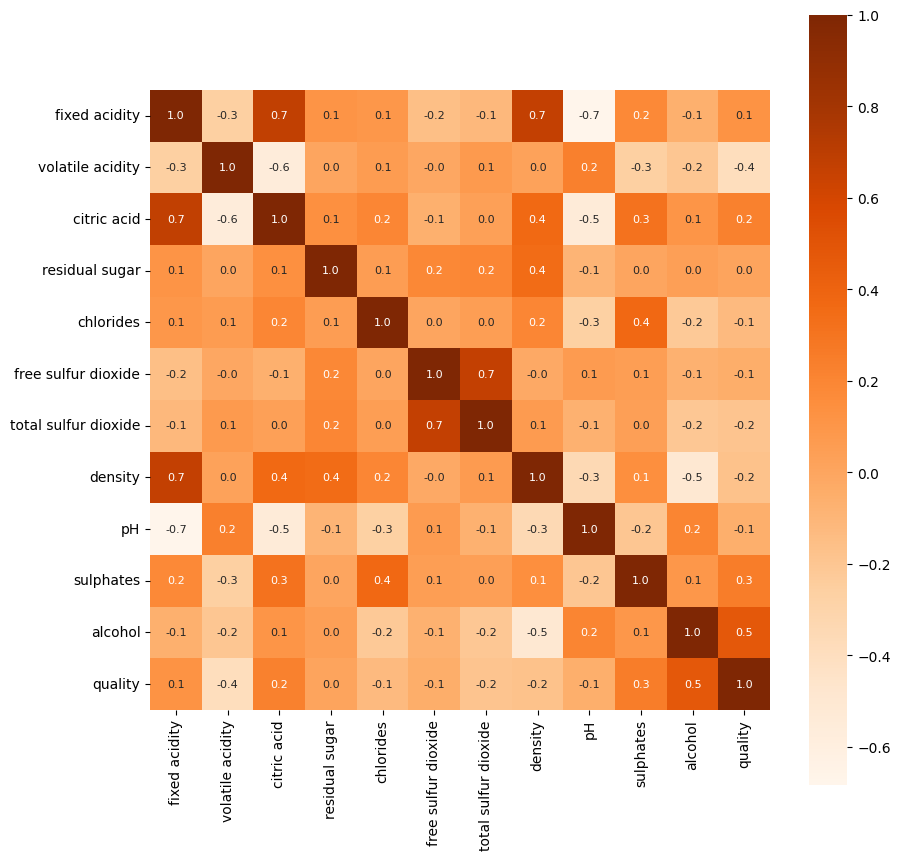

In [52]:
#using heatmap to find correlation
plt.figure(figsize = (10,10))
sns.heatmap(correlation, cbar = True, square = True, fmt = '.1f', annot = True, annot_kws = {'size': 8}, cmap = 'Oranges')
plt.show()

Data Preprocessing

In [53]:
X = wine_dataset.drop('quality', axis = 1)
Y = wine_dataset['quality']

In [54]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


Label Binarization: We will only give either 0 or 1 to the quality

If quality >= 7 -> 1
else 0


In [55]:
Y = Y.apply(lambda y_value: 1 if y_value >= 7 else 0)

In [56]:
Y.head()

,quality
0,0
1,0
2,0
3,0
4,0


In [57]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

In [58]:
X_train.shape

(1279, 11)

In [59]:
X_test.shape

(320, 11)

Training the model

In [60]:
model = RandomForestClassifier()

In [61]:
model.fit(X_train, Y_train)

RandomForestClassifier()

In [62]:
#evaluating the model
X_train_prediction = model.predict(X_train)
training_accuracy = accuracy_score(X_train_prediction, Y_train)
print('training data accuracy = ' ,training_accuracy * 100)

training data accuracy =  100.0


In [63]:
X_test_prediction = model.predict(X_test)
test_accuracy = accuracy_score(X_test_prediction, Y_test)
print('testing data accuracy = ', test_accuracy * 100)

testing data accuracy =  92.1875


In [64]:
#make the predictive system
def predict_quality(input_data):
  input_data_as_numpy_array = np.asarray(input_data)
  input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
  prediction = model.predict(input_data_reshaped)
  if(prediction[0] == 1):
    print('Good Quality Wine')
  else:
    print('Bad Quality Wine')


In [73]:
predict_quality(X.iloc[200])

Good Quality Wine


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
